10.	Perform Multilayer perception neural network to classify flower type. Utilize number of hidden layer 5 and 200 to 400 iteration with learning rate. Try with different loss functions/ activation functions such as MSE, Cross entropy, sigmoid, tanh, ReLU along with different optimizer GD, SGD, Adam. Illustrate the result with performance metrics and observe Weight, Loss curve and accuracy curve.

Dataset: Iris dataset


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD, Adam

In [ ]:
df = pd.read_csv("iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

In [ ]:
X = df.drop('species', axis=1)
y = to_categorical(df['species'])

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
def build_model(activation='relu', loss='categorical_crossentropy', optimizer='adam'):
    model = Sequential()
    model.add(Dense(64, input_dim=4, activation=activation))
    for _ in range(4):  # 5 hidden layers total
        model.add(Dense(64, activation=activation))
    model.add(Dense(3, activation='softmax'))  # Output layer for 3 classes
    model.compile(loss=loss, optimizer=optimizer, metrics=['accuracy'])
    return model

In [ ]:
activation_fn = 'tanh'             # Options: 'relu', 'sigmoid', 'tanh'
loss_fn = 'categorical_crossentropy'  # or 'mse'
optimizer = Adam(learning_rate=0.01)

In [ ]:
model = build_model(activation=activation_fn, loss=loss_fn, optimizer=optimizer)
history = model.fit(X_train, y_train, epochs=300, validation_data=(X_test, y_test), verbose=0)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy:.3f} | Test Loss: {loss:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 1.0000 - loss: 0.0103

Test Accuracy: 1.000 | Test Loss: 0.010


In [ ]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

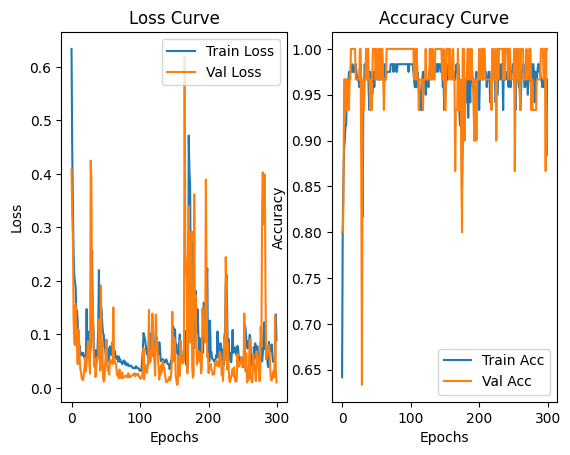

In [ ]:
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [ ]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
print("\nSample Weights from First Layer:")
print(model.get_weights()[0])


Sample Weights from First Layer:
[[ 1.68803588e-01  1.33172749e-02  4.79595363e-02 -5.66533208e-02
  -1.96194366e-01  3.11085284e-01  8.88667405e-02 -1.20578192e-01
  -4.98532876e-02  3.37538198e-02 -1.04549050e-01  6.59766793e-03
   1.94494903e-01 -8.03117305e-02 -4.59433533e-03  2.10716158e-01
   3.25123340e-01 -3.42965335e-01 -1.82150915e-01  2.27680542e-02
  -3.29430737e-02 -1.32696822e-01 -1.67259350e-02  3.29122782e-01
   5.88368922e-02 -1.72348157e-01  2.91874595e-02 -1.65592823e-02
  -1.56631336e-01  3.96894384e-03 -1.28439233e-01  1.32003561e-01
  -2.54673272e-01  2.11055905e-01  2.45970741e-01  1.10739447e-01
  -1.82669424e-02  2.37827718e-01 -1.52669206e-01  1.36340573e-01
  -1.76025182e-01  3.61002624e-01  7.91206025e-04  4.78788018e-02
   2.90507883e-01 -1.03872865e-01 -1.59416094e-01  1.71925396e-01
  -9.50577632e-02 -8.89923573e-02 -6.71328530e-02  3.07957619e-01
   3.04742660e-02  1.72401946e-02  3.60012166e-02 -3.97190824e-02
   2.57878862e-02 -1.53977424e-01 -1.29539